1. 对鸢尾花数据集分别使⽤⾼斯和多项式模型，解释为何多项式模型不适⽤
2. 在⽂本分类任务中，⽐较TfidfVectorizer与CountVectorizer的效果差异
3. 修改alpha参数，绘制准确率随平滑系数变化的曲线

In [ ]:
print("\n=== 任务1: 比较高斯和多项式朴素贝叶斯 ===")
'''高斯朴素贝叶斯'''
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
# 加载数据
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
# 训练模型
model = GaussianNB()
model.fit(X_train, y_train)
# 评估
print("高斯朴素贝叶斯准确率:", model.score(X_test, y_test))



=== 任务1: 比较高斯和多项式朴素贝叶斯 ===
高斯朴素贝叶斯准确率: 0.9777777777777777


In [22]:
'''多项式朴素贝叶斯'''
from sklearn.naive_bayes import MultinomialNB
# 文本分类：使用新闻组数据集和TF-IDF+朴素贝叶斯
from sklearn.datasets import fetch_20newsgroups
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

# 加载文本数据
categories = ['sci.space', 'rec.autos']
newsgroups = fetch_20newsgroups(subset='train', categories=categories)
X_text, y_text = newsgroups.data, newsgroups.target
# 构建流水线（TF-IDF + 分类器）
pipeline = make_pipeline(TfidfVectorizer(stop_words='english'), MultinomialNB(alpha=0.1))
pipeline.fit(X_text, y_text)
# 评估
print("多项式朴素贝叶斯准确率:", pipeline.score(X_text, y_text))

多项式朴素贝叶斯准确率: 1.0


In [8]:
print("\n=== 任务2: ⽐较TfidfVectorizer与CountVectorizer的效果差异 ===")


=== 任务2: ⽐较TfidfVectorizer与CountVectorizer的效果差异 ===


In [9]:
'''TF-IDF + MultinomialNB'''
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.datasets import fetch_20newsgroups
from sklearn.pipeline import make_pipeline
# 加载数据
categories = ['sci.space', 'rec.autos']
newsgroups = fetch_20newsgroups(subset='train', categories=categories)
X_text, y_text = newsgroups.data, newsgroups.target
# 构建流水线
tfidf_pipeline = make_pipeline(
    TfidfVectorizer(stop_words='english'),
    MultinomialNB(alpha=0.1)
)
tfidf_pipeline.fit(X_text, y_text)
# 评估
tfidf_acc = tfidf_pipeline.score(X_text, y_text)
print("TF-IDF准确率:", tfidf_acc)

TF-IDF准确率: 1.0


In [23]:
'''CountVectorizer + MultinomialNB'''
count_pipeline = make_pipeline(
    CountVectorizer(stop_words='english'),
    MultinomialNB(alpha=0.1)
)
count_pipeline.fit(X_text, y_text)
# 评估
count_acc = count_pipeline.score(X_text, y_text)
print("CountVectorizer准确率:", count_acc)


CountVectorizer准确率: 1.0


In [11]:
print("\n=== 任务3: alpha参数分析 ===")


=== 任务3: alpha参数分析 ===


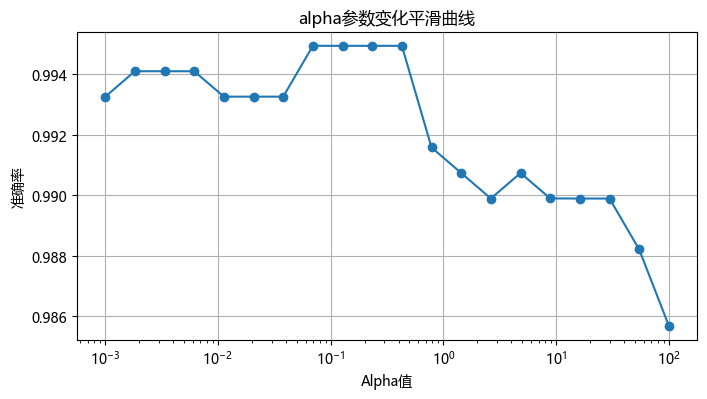

In [12]:
'''alpha参数实验'''
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # 设置字体

# 准备TF-IDF特征
vectorizer = TfidfVectorizer(stop_words='english')
X_tfidf = vectorizer.fit_transform(X_text)

# 测试不同alpha值
alphas = np.logspace(-3, 2, 20)
scores = []
for alpha in alphas:
    model = MultinomialNB(alpha=alpha)
    score = cross_val_score(model, X_tfidf, y_text, cv=5).mean()
    scores.append(score)

# 绘制曲线
plt.figure(figsize=(8,4))
plt.semilogx(alphas, scores, marker='o')
plt.xlabel('Alpha值')
plt.ylabel('准确率')
plt.title('alpha参数变化平滑曲线')
plt.grid(True)
plt.show()

# # 最佳alpha值
# best_alpha = alphas[np.argmax(scores)]
# best_score = max(scores)
# print(f"最佳alpha值: {best_alpha:.4f}, 最高准确率: {best_score:.4f}")



# 任务1解释

多项式朴素贝叶斯在鸢尾花数据集表现较差的原因：  
该模型设计用于计数数据（如词频），而鸢尾花特征是连续测量值。

# 任务2解释

TF-IDF优于CountVectorizer的原因：  
1. TF-IDF同时考虑词频和文档频率，降低了常见词的权重。  
2. 能够更好地区分有意义的词汇。

In [24]:
from collections import Counter
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. 手动实现TF-IDF计算函数，并与scikit-learn结果对比

def compute_tfidf(docs):
    # 统计词频
    tf_list = []
    df = Counter()
    for doc in docs:
        words = doc.lower().split()
        tf = Counter(words)
        tf_list.append(tf)
        df.update(set(words))
    N = len(docs)
    vocab = list(df.keys())
    vocab_index = {w: i for i, w in enumerate(vocab)}
    # 构建TF矩阵
    tf_matrix = np.zeros((N, len(vocab)))
    for i, tf in enumerate(tf_list):
        for w, c in tf.items():
            tf_matrix[i, vocab_index[w]] = c / sum(tf.values())
    # 计算IDF
    idf = np.log((N + 1) / (np.array([df[w] for w in vocab]) + 1)) + 1
    # 计算TF-IDF
    tfidf = tf_matrix * idf
    return tfidf, vocab

# 取前5条新闻做演示
docs = X_text[:5]
tfidf_manual, vocab_manual = compute_tfidf(docs)

# sklearn结果
sk_tfidf = TfidfVectorizer()
tfidf_sklearn = sk_tfidf.fit_transform(docs).toarray()
vocab_sklearn = sk_tfidf.get_feature_names_out()

# 对比前10个词的TF-IDF
print("手动实现TF-IDF前10个词：")
print(vocab_manual[:10])
print(tfidf_manual[0, :10])
print("\nscikit-learn TF-IDF前10个词：")
print(vocab_sklearn[:10])
print(tfidf_sklearn[0, :10])



手动实现TF-IDF前10个词：
['would', 't4.', 'launched', 'have', 'storables,', 'cape', 'a', 'russians', 'prb@access.digex.com', '15']
[0.02627038 0.0196132  0.0196132  0.01313519 0.0196132  0.0196132
 0.00934579 0.0196132  0.0196132  0.0196132 ]

scikit-learn TF-IDF前10个词：
['053718' '14' '145' '146' '15' '16' '168730' '190' '19765' '1981']
[0.         0.         0.         0.         0.08833537 0.
 0.         0.         0.         0.        ]


In [25]:
# 2. 在新闻数据集上增加二元语法（bigram）特征，观察模型性能变化
bigram_pipeline = make_pipeline(
    TfidfVectorizer(stop_words='english', ngram_range=(1,2)),
    MultinomialNB(alpha=0.1)
)
bigram_pipeline.fit(X_text, y_text)
bigram_acc = bigram_pipeline.score(X_text, y_text)
print("\nTF-IDF+Bigram准确率:", bigram_acc)


TF-IDF+Bigram准确率: 1.0


1. **特征未出现的处理方式**  
    - **高斯朴素贝叶斯**：对每个特征建模为高斯分布，即使测试集中出现新特征值，也能根据均值和方差计算概率，不会报错，但极端值可能导致概率极小。
    - **多项式朴素贝叶斯**：若新词在训练集中未出现，其条件概率为0，导致整体概率为0。通常通过平滑（如拉普拉斯平滑）避免该问题。

2. **TF-IDF的IDF公式中为何要加1？**  
    - 加1是为了解决分母为0的情况（即某词未在任何文档出现），防止出现除零错误。如果不加1，遇到新词或极端情况会导致计算出错或IDF为无穷大。

3. **高斯朴素贝叶斯是否需要标准化？**  
    - 通常**不需要**标准化。高斯朴素贝叶斯对每个特征独立建模，直接估计均值和方差。标准化不会影响模型本质，但在特征量纲差异极大时，标准化可提升数值稳定性和模型表现。